# 🧹 Notebook 02 — Tiền xử lý NLP

**Mục tiêu:**
- Làm sạch văn bản tiếng Việt (HTML, emoji, ký tự đặc biệt)
- Chuẩn hóa teencode / từ viết tắt
- Tách từ (Tokenization) với `underthesea`
- Loại bỏ Stopwords tiếng Việt
- POS Tagging — giữ lại Noun, Verb, Adjective
- TF-IDF Vectorization với N-gram (1,3)
- Lưu vectorizer và processed data

**Đầu vào:** `datas/processed/merged_sentiment.csv`  
**Đầu ra:** `datas/processed/processed_reviews.csv`, `datas/processed/tfidf_vectorizer.pkl`

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import joblib
import warnings
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

try:
    from underthesea import word_tokenize, pos_tag
    UNDERTHESEA_AVAILABLE = True
    print('✅ underthesea sẵn sàng')
except ImportError:
    UNDERTHESEA_AVAILABLE = False
    print('⚠️  underthesea chưa được cài đặt. Dùng tokenizer đơn giản.')

warnings.filterwarnings('ignore')
tqdm.pandas()

ROOT_DIR = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'datas' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'✅ ROOT_DIR: {ROOT_DIR}')

✅ underthesea sẵn sàng
✅ ROOT_DIR: F:\codingSpace\Asm\ecom_rcm_1


## 2. Tải dữ liệu đã gộp

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'merged_sentiment.csv')
print(f'✅ Đã tải: {df.shape}')
print(f'Phân phối nhãn: {df["label"].value_counts().to_dict()}')
display(df.head(3))

✅ Đã tải: (32170, 3)
Phân phối nhãn: {1: 19873, 0: 12297}


,review_text,label,source
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,1,tiki_sentiment
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,1,tiki_sentiment
2,Bố t thích áo này lắm y.,1,tiki_sentiment


## 3. Từ điển chuẩn hóa Teencode / Viết tắt

In [3]:
# Từ điển teencode tiếng Việt thường gặp trong bình luận e-commerce
TEENCODE_DICT = {
    # Sản phẩm
    'sp': 'sản phẩm', 'hàng': 'hàng hóa', 'ht': 'hàng thật',
    'hg': 'hàng giả',
    # Phủ định
    'ko': 'không', 'k': 'không', 'khong': 'không', 'kh': 'không',
    'kg': 'không', 'hok': 'không',
    # Chất lượng
    'ok': 'được', 'oke': 'được', 'okela': 'được', 'oce': 'được',
    'tốt': 'tốt', 'xịn': 'chất lượng tốt', 'xin': 'chất lượng tốt',
    'ck': 'chồng', 'vk': 'vợ',
    # Giao hàng
    'gh': 'giao hàng', 'ship': 'giao hàng', 'shipper': 'người giao hàng',
    'đvvc': 'đơn vị vận chuyển', 'vc': 'vận chuyển',
    # Cảm xúc
    'vs': 'với', 'dc': 'được', 'đc': 'được', 'đk': 'được',
    'bt': 'bình thường', 'bth': 'bình thường',
    # Thời gian
    'mình': 'tôi', 'mk': 'tôi', 'mik': 'tôi',
    'j': 'gì', 'wa': 'quá', 'qá': 'quá', 'lm': 'làm',
    'hok': 'không', 'ntn': 'như thế nào', 'đb': 'đặc biệt',
    'cx': 'cũng', 'nx': 'nữa', 'ms': 'mới', 'ad': 'admin',
    'shop': 'cửa hàng', 'mn': 'mọi người', 'ae': 'anh em',
    'tks': 'cảm ơn', 'thanks': 'cảm ơn', 'thx': 'cảm ơn',
}

print(f'✅ Từ điển teencode: {len(TEENCODE_DICT)} từ')

✅ Từ điển teencode: 49 từ


## 4. Pipeline làm sạch văn bản

In [4]:
# Danh sách stopwords tiếng Việt cơ bản (sẽ mở rộng nếu cài underthesea)
VIETNAMESE_STOPWORDS = {
    'và', 'là', 'của', 'có', 'trong', 'để', 'với', 'một', 'được', 'cho',
    'những', 'này', 'đã', 'tôi', 'mình', 'bạn', 'rất', 'cũng', 'từ',
    'như', 'nhưng', 'khi', 'về', 'thì', 'không', 'nên', 'phải', 'vì',
    'lại', 'đây', 'thế', 'các', 'mà', 'đó', 'cái', 'hay', 'vẫn', 'đều',
    'hơn', 'ra', 'thôi', 'nào', 'lắm', 'luôn', 'ai', 'gì', 'bao',
    'tuy', 'dù', 'vậy', 'nên', 'xong', 'đã', 'sẽ', 'đang', 'bị', 'được'
}

# Biên dịch regex một lần cho hiệu năng tốt hơn
RE_HTML = re.compile(r'<[^>]+>')
RE_URL = re.compile(r'https?://\S+|www\.\S+')
RE_EMAIL = re.compile(r'\S+@\S+')
RE_EMOJI = re.compile("["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U00002702-\U000027B0"
    u"\U000024C2-\U0001F251"
    "]+", flags=re.UNICODE)
RE_SPECIAL_CHARS = re.compile(r'[^\w\s\u00C0-\u024F\u1E00-\u1EFF]')
RE_WHITESPACE = re.compile(r'\s+')


def clean_text(text: str) -> str:
    """Làm sạch văn bản: loại HTML, URL, emoji, ký tự đặc biệt."""
    if not isinstance(text, str):
        return ''
    text = RE_HTML.sub(' ', text)          # Loại HTML tags
    text = RE_URL.sub(' ', text)           # Loại URL
    text = RE_EMAIL.sub(' ', text)         # Loại email
    text = RE_EMOJI.sub(' ', text)         # Loại emoji
    text = text.lower()                    # Lowercase
    text = RE_SPECIAL_CHARS.sub(' ', text) # Loại ký tự đặc biệt
    text = RE_WHITESPACE.sub(' ', text)    # Chuẩn hóa khoảng trắng
    return text.strip()


def normalize_teencode(text: str, dictionary: dict = TEENCODE_DICT) -> str:
    """Chuẩn hóa teencode và từ viết tắt."""
    words = text.split()
    return ' '.join(dictionary.get(w, w) for w in words)


def tokenize_vietnamese(text: str) -> str:
    """Tách từ tiếng Việt với underthesea (hoặc split đơn giản nếu không có)."""
    if UNDERTHESEA_AVAILABLE:
        try:
            tokens = word_tokenize(text, format='text')
            return tokens
        except Exception:
            pass
    return text  # Fallback: giữ nguyên


def remove_stopwords(text: str, stopwords: set = VIETNAMESE_STOPWORDS) -> str:
    """Loại bỏ stopwords tiếng Việt."""
    words = text.split()
    return ' '.join(w for w in words if w not in stopwords and len(w) > 1)


def preprocess_text(text: str) -> str:
    """Pipeline tiền xử lý đầy đủ cho 1 văn bản."""
    text = clean_text(text)
    text = normalize_teencode(text)
    text = tokenize_vietnamese(text)
    text = remove_stopwords(text)
    return text


# Kiểm tra pipeline
test_reviews = [
    "sp này ok lắm, gh nhanh, ko có gì phàn nàn 😍",
    "hàng nhận được k giống ảnh, chất lượng kém, shop lừa đảo!!!",
    "Mua lần 2 rồi, tốt lắm, sẽ mua lại <br> <3"
]

print('=== Kiểm tra Pipeline Tiền xử lý ===')
for review in test_reviews:
    processed = preprocess_text(review)
    print(f'  IN:  {review}')
    print(f'  OUT: {processed}')
    print()

=== Kiểm tra Pipeline Tiền xử lý ===
  IN:  sp này ok lắm, gh nhanh, ko có gì phàn nàn 😍
  OUT: sản_phẩm giao hàng nhanh phàn_nàn

  IN:  hàng nhận được k giống ảnh, chất lượng kém, shop lừa đảo!!!
  OUT: hàng hóa nhận giống ảnh chất_lượng kém cửa_hàng lừa_đảo

  IN:  Mua lần 2 rồi, tốt lắm, sẽ mua lại <br> <3
  OUT: mua lần rồi tốt mua



## 5. Áp dụng pipeline lên toàn bộ dataset

In [5]:
print('🔄 Đang tiền xử lý toàn bộ dataset...')
df['processed_text'] = df['review_text'].progress_apply(preprocess_text)

# Loại bỏ các dòng sau xử lý bị rỗng
df = df[df['processed_text'].str.len() > 3].reset_index(drop=True)

print(f'\n✅ Hoàn thành! Còn lại: {len(df):,} bình luận')
print('\nMẫu kết quả:')
display(df[['review_text', 'processed_text', 'label']].head(5))

🔄 Đang tiền xử lý toàn bộ dataset...


100%|██████████| 32170/32170 [00:15<00:00, 2083.73it/s]


✅ Hoàn thành! Còn lại: 31,872 bình luận

Mẫu kết quả:


,review_text,processed_text,label
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,tốt gói hàng hóa đẹp cửa_hàng phục_vụ tốt,1
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,nhận hàng hóa rồi đẹp cảm_ơn cửa_hàng nhé,1
2,Bố t thích áo này lắm y.,bố thích áo,1
3,"Shop còn có quà cho khách nữa, rất hài lòng , ...",cửa_hàng còn quà khách nữa hài_lòng tiếp_tục ủ...,1
4,76347487068,76347487068,0


## 6. TF-IDF Vectorization

In [6]:
# Khởi tạo và fit TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1, 3),       # N-gram từ 1 đến 3
    max_features=50_000,       # Giới hạn số từ vựng
    min_df=3,                  # Bỏ qua từ xuất hiện < 3 lần
    max_df=0.95,               # Bỏ qua từ xuất hiện > 95% tài liệu
    sublinear_tf=True,         # Áp dụng log(tf+1)
)

X = tfidf.fit_transform(df['processed_text'])
y = df['label'].values

print(f'✅ TF-IDF Matrix: {X.shape}')
print(f'   Số features: {len(tfidf.vocabulary_):,}')
print(f'   Top 20 từ: {list(tfidf.vocabulary_.keys())[:20]}')

✅ TF-IDF Matrix: (31872, 10717)
   Số features: 10,717
   Top 20 từ: ['tốt', 'gói', 'hàng', 'hóa', 'đẹp', 'cửa_hàng', 'phục_vụ', 'gói hàng', 'hàng hóa', 'hóa đẹp', 'đẹp cửa_hàng', 'cửa_hàng phục_vụ', 'phục_vụ tốt', 'gói hàng hóa', 'hàng hóa đẹp', 'hóa đẹp cửa_hàng', 'đẹp cửa_hàng phục_vụ', 'cửa_hàng phục_vụ tốt', 'nhận', 'rồi']


In [7]:
# Train/Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train set: {X_train.shape[0]:,} mẫu')
print(f'   Test set:  {X_test.shape[0]:,} mẫu')
print(f'   Train label dist: {pd.Series(y_train).value_counts().to_dict()}')
print(f'   Test label dist:  {pd.Series(y_test).value_counts().to_dict()}')

✅ Train set: 25,497 mẫu
   Test set:  6,375 mẫu
   Train label dist: {1: 15708, 0: 9789}
   Test label dist:  {1: 3928, 0: 2447}


## 7. Visualize: WordCloud

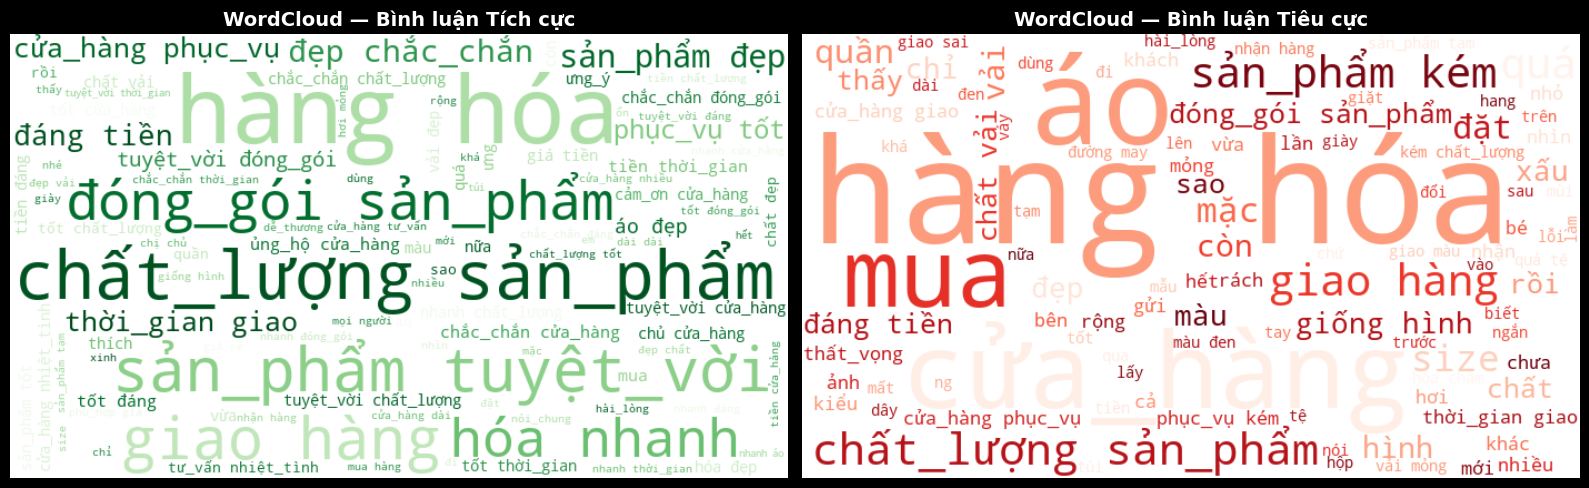

✅ WordCloud đã lưu tại datas/processed/wordcloud.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (label_val, label_name, color) in enumerate([
    (1, 'Tích cực', 'Greens'),
    (0, 'Tiêu cực', 'Reds')
]):
    corpus = ' '.join(df[df['label'] == label_val]['processed_text'].dropna())
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=color,
        max_words=100,
        font_path=None,  # Đổi sang font tiếng Việt nếu có
    ).generate(corpus)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'WordCloud — Bình luận {label_name}',
                      fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ WordCloud đã lưu tại datas/processed/wordcloud.png')

## 8. Lưu kết quả

In [9]:
import scipy.sparse as sp

# Lưu dataset đã xử lý
df[['review_text', 'processed_text', 'label', 'source']].to_csv(
    PROCESSED_DIR / 'processed_reviews.csv',
    index=False, encoding='utf-8-sig'
)

# Lưu TF-IDF vectorizer
joblib.dump(tfidf, PROCESSED_DIR / 'tfidf_vectorizer.pkl')

# Lưu split data (sparse matrix)
sp.save_npz(str(PROCESSED_DIR / 'X_train.npz'), X_train)
sp.save_npz(str(PROCESSED_DIR / 'X_test.npz'), X_test)
np.save(str(PROCESSED_DIR / 'y_train.npy'), y_train)
np.save(str(PROCESSED_DIR / 'y_test.npy'), y_test)

print('✅ Phase 2 hoàn thành! Các file đã lưu:')
print(f'  - datas/processed/processed_reviews.csv')
print(f'  - datas/processed/tfidf_vectorizer.pkl')
print(f'  - datas/processed/X_train.npz, X_test.npz')
print(f'  - datas/processed/y_train.npy, y_test.npy')
print('\n📌 Tiếp theo: Chạy Notebook 03 - Phân cụm & Phân lớp')

✅ Phase 2 hoàn thành! Các file đã lưu:
  - datas/processed/processed_reviews.csv
  - datas/processed/tfidf_vectorizer.pkl
  - datas/processed/X_train.npz, X_test.npz
  - datas/processed/y_train.npy, y_test.npy

📌 Tiếp theo: Chạy Notebook 03 - Phân cụm & Phân lớp
